# Variational Inference

A common problem with Bayesian Inference is the intractable calculation of the normalization constant $Z$ when calculating the posterior

$$
p(\theta|\mathcal{D}) = \frac{1}{Z}p(\mathcal{D}|\theta)p(\theta)
$$

which is why there are approximation methods of the posterior. These rely on simpler, tractable approximations. One of these methods is called variational inference, where we approximate $p$ with a simpler distribution.

In [1]:
%load_ext autoreload
%autoreload 2

import torch

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from pai import bayesian_log_reg_laplace, bayesian_logistic_vi

mpl.rc_file_defaults()

## Laplace Approximation

Another, even simpler approach is the Laplace Approximation. It is not a form of variational inference, but it has similar elements. In this approach, the true distribution is approximated using a Gaussian distribution. The mean is approximated as the mode of the posterior, and the covariance matrix using the inverse observed Fisher information.

In [2]:
rng = np.random.default_rng(seed=43)

num_samples_per_class = 100
num_features = 2

# Mean vectors for the two classes
mean_0 = np.array([-2.0, -2.0])
mean_1 = np.array([2.0, 2.0])

# Covariance matrices
cov = np.eye(num_features)

# Draw samples from the two Gaussian distributions
x_0 = rng.multivariate_normal(
    mean=mean_0, cov=cov,
    size=num_samples_per_class,
)

x_1 = rng.multivariate_normal(
    mean=mean_1, cov=cov,
    size=num_samples_per_class,
)

# Combine the feature vectors
x_numpy = np.concatenate([x_0, x_1], axis=0)

# Create the corresponding class labels
y_numpy = np.concatenate([
    -np.ones(num_samples_per_class, dtype=int),
    np.ones(num_samples_per_class, dtype=int),
])

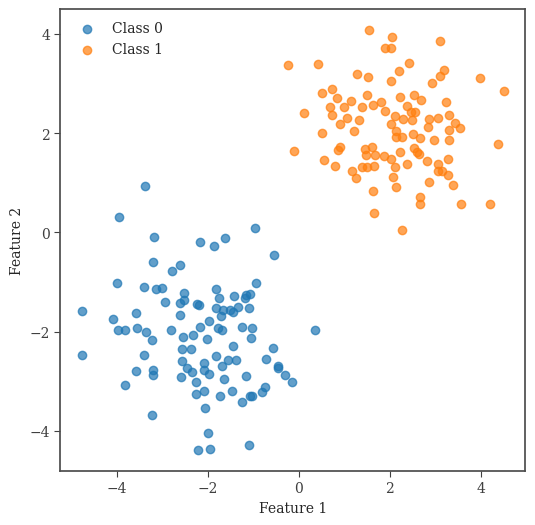

In [3]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(
    x_numpy[y_numpy == -1, 0], x_numpy[y_numpy == -1, 1],
    label="Class 0", alpha=0.7,
)

ax.scatter(
    x_numpy[y_numpy == 1, 0], x_numpy[y_numpy == 1, 1],
    label="Class 1", alpha=0.7,
)

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.legend()

plt.show()

In [4]:
x = torch.from_numpy(x_numpy).to(torch.float32)
y = torch.from_numpy(y_numpy).to(torch.float32)

w, b, posterior_covariance = bayesian_log_reg_laplace(x, y)

Epoch 100: Loss 4.6959
Epoch 200: Loss 4.1568
Epoch 300: Loss 4.0455
Epoch 400: Loss 4.0118
Epoch 500: Loss 3.9990


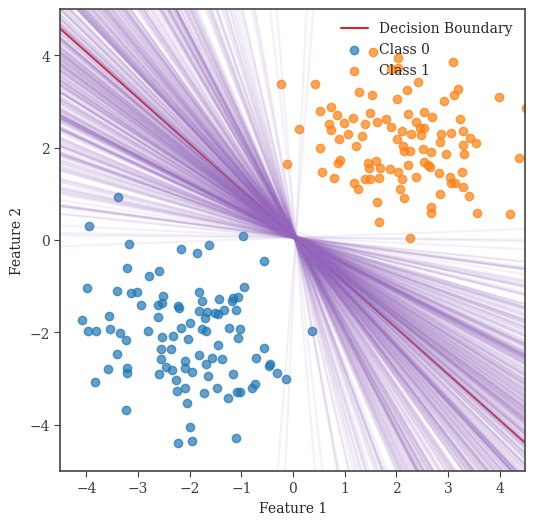

In [5]:
fig, ax = plt.subplots(figsize=(6, 6))

w_numpy = w.detach().numpy()
b_numpy = b.detach().numpy()

x_space = np.arange(-5, 6)
y_line = -(w_numpy[0] * x_space + b_numpy) / w_numpy[1]

ax.plot(x_space, y_line, label="Decision Boundary", color="C03")
ax.scatter(x_numpy[y_numpy == -1, 0], x_numpy[y_numpy == -1, 1], label="Class 0", alpha=0.7)
ax.scatter(x_numpy[y_numpy == 1, 0], x_numpy[y_numpy == 1, 1], label="Class 1", alpha=0.7)

posterior = torch.distributions.MultivariateNormal(
    loc=w.detach(), covariance_matrix=posterior_covariance,
)

weight_samples = posterior.sample((500,))

x_values = torch.linspace(
    x[:, 0].min(), x[:, 0].max(), 200
)

for sampled_w in weight_samples:
    sampled_y = -(
        sampled_w[0] * x_values + b.detach()
    ) / sampled_w[1]

    ax.plot(x_values, sampled_y, alpha=0.1, color="C04")


ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")

ax.legend()
ax.set_ylim(-5, 5)
ax.set_xlim(-4.5, 4.5)

plt.show()

Instead of a fixed weight vector, Laplace Approximations are able to approximate the posterior through the maximum a posteriori and the inverse of the fisher information. As the plot above shows, the output is a normal distribution over weight vectors.

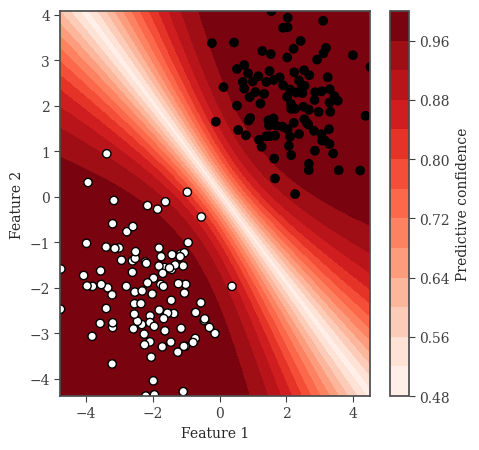

In [6]:
x1 = torch.linspace(x[:, 0].min(), x[:, 0].max(), 200)
x2 = torch.linspace(x[:, 1].min(), x[:, 1].max(), 200)

grid_x1, grid_x2 = torch.meshgrid(x1, x2, indexing="xy")

grid = torch.stack(
    [grid_x1.ravel(), grid_x2.ravel()],
    dim=1
)

with torch.no_grad():
    sampled_probabilities = torch.sigmoid(
        grid @ weight_samples.T + b
    )
    probabilities = sampled_probabilities.mean(dim=1)

confidence = torch.maximum(
    probabilities, torch.tensor(1.0) - probabilities,
).reshape(grid_x1.shape)

# Separate confidence plot
fig, ax = plt.subplots(figsize=(5, 5))

contour = ax.contourf(
    grid_x1, grid_x2, confidence,
    levels=15, cmap="Reds",
)
fig.colorbar(
    contour, ax=ax, label="Predictive confidence",
)

ax.scatter(x[:, 0], x[:, 1], c=y, edgecolors="black")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## Variational Inference

The idea behind variational inference is to minimize the KL-Divergence between the posterior and the variational distribution. This objective can, when rewritten, be interpreted as maximizing the evidence lower bound (ELBO)

$$
\text{arg} \max \mathbb{E}_{\theta \sim q}[\log p(\mathcal{D}|\theta)] - \text{KL}(q||p)
$$

In [7]:
x = torch.from_numpy(x_numpy).to(torch.float32)
x = torch.cat([x, torch.ones(x.shape[0], 1)], dim=1)
y = torch.from_numpy(y_numpy).to(torch.float32)

mu, posterior_covariance = bayesian_logistic_vi(x, y)

Epoch 100: Loss 0.9026
Epoch 200: Loss 1.4156
Epoch 300: Loss 0.7445
Epoch 400: Loss 0.8883
Epoch 500: Loss 1.5226
Epoch 600: Loss 1.1695
Epoch 700: Loss 1.8743
Epoch 800: Loss 0.9228
Epoch 900: Loss 1.8018
Epoch 1000: Loss 0.7662


A common problem here with the above definition is that we try to maximize an expression that we have to differentiate with respect to parameters that are used for the expected value. A common solution to this problem is the reparametrization trick, which is used below.

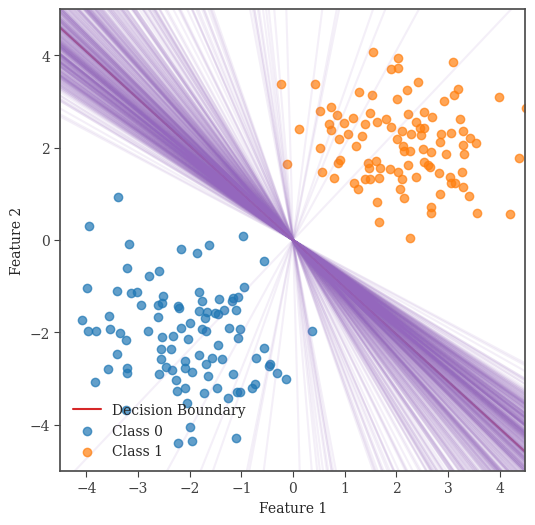

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))

mu_numpy = mu.detach().numpy()

x_space = np.arange(-5, 6)
y_line = -(mu_numpy[0] * x_space + mu_numpy[2]) / mu_numpy[1]

ax.plot(x_space, y_line, label="Decision Boundary", color="C03")
ax.scatter(x_numpy[y_numpy == -1, 0], x_numpy[y_numpy == -1, 1], label="Class 0", alpha=0.7)
ax.scatter(x_numpy[y_numpy == 1, 0], x_numpy[y_numpy == 1, 1], label="Class 1", alpha=0.7)

posterior = torch.distributions.MultivariateNormal(
    loc=mu.detach(), covariance_matrix=posterior_covariance.detach(),
)

weight_samples = posterior.sample((500,))

x_values = torch.linspace(
    x[:, 0].min(), x[:, 0].max(), 200
)

for sampled_w in weight_samples:
    sampled_y = -(
        sampled_w[0] * x_values + mu_numpy[2]
    ) / sampled_w[1]

    ax.plot(x_values, sampled_y, alpha=0.1, color="C04")


ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")

ax.legend()
ax.set_ylim(-5, 5)
ax.set_xlim(-4.5, 4.5)

plt.show()

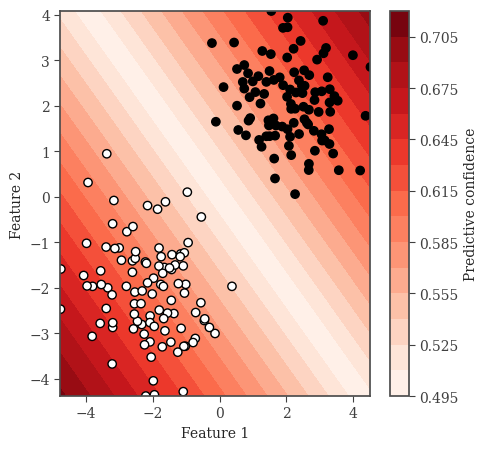

In [9]:
x1 = torch.linspace(x[:, 0].min(), x[:, 0].max(), 200)
x2 = torch.linspace(x[:, 1].min(), x[:, 1].max(), 200)

grid_x1, grid_x2 = torch.meshgrid(x1, x2, indexing="xy")

grid = torch.stack(
    [grid_x1.ravel(), grid_x2.ravel()],
    dim=1
)

with torch.no_grad():
    sampled_probabilities = torch.sigmoid(
        grid @ weight_samples[:, :2].T + mu_numpy[2]
    )
    probabilities = sampled_probabilities.mean(dim=1)

confidence = torch.maximum(
    probabilities, torch.tensor(1.0) - probabilities,
).reshape(grid_x1.shape)

# Separate confidence plot
fig, ax = plt.subplots(figsize=(5, 5))

contour = ax.contourf(
    grid_x1, grid_x2, confidence,
    levels=15, cmap="Reds",
)
fig.colorbar(
    contour, ax=ax, label="Predictive confidence",
)

ax.scatter(x[:, 0], x[:, 1], c=y, edgecolors="black")

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
plt.show()

Above we can see, that using Variational Inference, the predictive confidence changes.